# Analysis of Neuronal Exon Inclusion Changes Over Time

In [11]:
!pip install ipykernel
!python -m ipykernel install --user --name finalproject --display-name "Python (final project)"

Installed kernelspec finalproject in /home/biouser/.local/share/jupyter/kernels/finalproject


In [12]:
## 0. Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from functions import (
    load_type_data,
    compute_spearman_corr,
    spearman_corr_labels,
    preprocess_type,
    load_subtype_data,
    preprocess_subtype,
    compute_spearman_ci,
)

In [13]:
## Define colour palettes

# Ages 
ages = ["P14", "P21", "P28", "P56"]
ages_colour = ["#ae3b24", "#c8812a", "#56632c" ,"#f68d62"]
ages_palette = dict(zip(ages, ages_colour))

# Regions
regions = ["VIS", "HIPP"]
regions_colour = ["#ddbbc6", "#fdc681"]
regions_palette = dict(zip(regions, regions_colour))

# Cell types
cts = ["Excite", "Inhib"]
cts_colour = ["#ffcc5c", "#65c3ba"]
cts_palette = dict(zip(cts, cts_colour))

## 1. Load Data
- Load `altExonUsage_devel_type.gz`
- Filter only column with `Neuron` 
- Combine `Exon` and `Gene` to `GE` (`Exon::Gene`)
- Remove rows with missing data `NaN`

In [14]:
type_neurons = load_type_data("../../data/altExonUsage_devel_type.gz")
type_neurons.head(10)

,P14_Hippocampus_ExciteNeuron,P14_Hippocampus_InhibNeuron,P14_VisCortex_ExciteNeuron,P14_VisCortex_InhibNeuron,P21_Hippocampus_ExciteNeuron,P21_Hippocampus_InhibNeuron,P21_VisCortex_ExciteNeuron,P21_VisCortex_InhibNeuron,P28_Hippocampus_ExciteNeuron,P28_Hippocampus_InhibNeuron,P28_VisCortex_ExciteNeuron,P28_VisCortex_InhibNeuron,P56_Hippocampus_ExciteNeuron,P56_Hippocampus_InhibNeuron,P56_VisCortex_ExciteNeuron,P56_VisCortex_InhibNeuron
GE,,,,,,,,,,,,,,,,
chr1_162273620_162273649_-::ENSMUSG00000040265.16,0.032520,0.000000,0.008152,0.000000,0.049351,0.024000,0.000000,0.000000,0.015544,0.007812,0.001163,0.000000,0.015831,0.026316,0.005181,0.001821
chr1_83384894_83384972_-::ENSMUSG00000026163.17,0.608364,0.642140,0.707604,0.657718,0.631307,0.707113,0.767779,0.776471,0.670919,0.666667,0.789824,0.805970,0.641826,0.694915,0.781662,0.712150
chr1_16486020_16486150_-::ENSMUSG00000025920.19,0.204724,0.032967,0.240229,0.097222,0.222116,0.230769,0.275465,0.102564,0.223958,0.000000,0.230177,0.132075,0.218418,0.050633,0.220895,0.145867
chr1_30837105_30837266_-::ENSMUSG00000048874.15,0.159420,0.082569,0.141469,0.195122,0.148862,0.163043,0.153000,0.217391,0.192575,0.172414,0.170354,0.205882,0.128942,0.253333,0.183346,0.246057
chr1_42663556_42663602_-::ENSMUSG00000060424.14,0.313793,0.322222,0.341404,0.342593,0.353125,0.354167,0.423520,0.370968,0.304668,0.275862,0.426385,0.526316,0.388466,0.400000,0.439563,0.340741
chr1_84795690_84795815_-::ENSMUSG00000026219.14,0.288591,0.472222,0.331536,0.444444,0.320594,0.327273,0.362587,0.466667,0.322695,0.523810,0.380399,0.363636,0.278626,0.428571,0.391031,0.355769
chr1_121312201_121312325_-::ENSMUSG00000003721.14,0.891176,0.910448,0.803970,0.846154,0.797701,0.858974,0.817054,0.812500,0.903448,0.833333,0.898990,0.940000,0.806051,0.921569,0.849558,0.894118
chr1_121307140_121307306_-::ENSMUSG00000003721.14,0.896359,0.914286,0.814554,0.857143,0.800680,0.860759,0.824047,0.823529,0.906822,0.846154,0.902439,0.941176,0.812874,0.927273,0.850332,0.892000
chr1_133004654_133004721_-::ENSMUSG00000054387.13,0.994475,0.804348,0.975676,0.857143,0.845659,0.406977,0.786689,0.394737,0.938511,0.842105,0.965812,0.851852,0.964720,0.722222,0.947581,0.783784


## 2. Performn Pairwise Correlation

- Compute Spearman correlation matrix
- Rename indices "Hippocampus" -> "HIPP" & "VisCortex" -> "VIS" 

In [16]:
CN = compute_spearman_corr(type_neurons)
CN = preprocess_type(CN)
CN

,P14_HIPP_Excite,P14_HIPP_Inhib,P14_VIS_Excite,P14_VIS_Inhib,P21_HIPP_Excite,P21_HIPP_Inhib,P21_VIS_Excite,P21_VIS_Inhib,P28_HIPP_Excite,P28_HIPP_Inhib,P28_VIS_Excite,P28_VIS_Inhib,P56_HIPP_Excite,P56_HIPP_Inhib,P56_VIS_Excite,P56_VIS_Inhib
P14_HIPP_Excite,1.000000,0.884217,0.962237,0.899971,0.971003,0.868121,0.947010,0.860983,0.949210,0.850278,0.943170,0.880083,0.961826,0.902950,0.934050,0.886542
P14_HIPP_Inhib,0.884217,1.000000,0.878134,0.910373,0.870207,0.916648,0.853516,0.846149,0.863946,0.909185,0.855788,0.883274,0.869281,0.925440,0.854794,0.904063
P14_VIS_Excite,0.962237,0.878134,1.000000,0.925685,0.954540,0.876602,0.964306,0.877206,0.928853,0.850946,0.958362,0.900242,0.935769,0.900521,0.946463,0.906316
P14_VIS_Inhib,0.899971,0.910373,0.925685,1.000000,0.890136,0.889708,0.888126,0.880438,0.871564,0.882559,0.886951,0.917194,0.883123,0.912734,0.880189,0.913409
P21_HIPP_Excite,0.971003,0.870207,0.954540,0.890136,1.000000,0.886830,0.973686,0.887591,0.968928,0.860166,0.964302,0.892825,0.981593,0.917818,0.965583,0.909689
P21_HIPP_Inhib,0.868121,0.916648,0.876602,0.889708,0.886830,1.000000,0.892030,0.904615,0.879264,0.911842,0.881864,0.912125,0.874085,0.931539,0.885403,0.941667
P21_VIS_Excite,0.947010,0.853516,0.964306,0.888126,0.973686,0.892030,1.000000,0.912379,0.950948,0.858103,0.980269,0.900454,0.952490,0.905970,0.983004,0.925432
P21_VIS_Inhib,0.860983,0.846149,0.877206,0.880438,0.887591,0.904615,0.912379,1.000000,0.883744,0.859579,0.891405,0.899474,0.874334,0.891868,0.899297,0.925791
P28_HIPP_Excite,0.949210,0.863946,0.928853,0.871564,0.968928,0.879264,0.950948,0.883744,1.000000,0.874911,0.966287,0.884917,0.970060,0.912727,0.951848,0.906948
P28_HIPP_Inhib,0.850278,0.909185,0.850946,0.882559,0.860166,0.911842,0.858103,0.859579,0.874911,1.000000,0.863372,0.891848,0.856964,0.916498,0.858614,0.912753


## 3. Heat Map of Pairwise Correlation for Excitatory and Inhibitory Types

- Extract metadata from the table's index to create labels for the heat map
    - `Age`, `Region`, `Type` 
- Create colour palettes for each label
- Create a cluster map
    - Dendrogram of excitatory type & inhitory type
    - Heat map of Spearman pairwise correlations of exon inclusion for each cell type 

In [17]:
# Create labels for the heatmap
cnn = spearman_corr_labels(CN)
cnn

,CT,Age,Region,Type
0,P14_HIPP_Excite,P14,HIPP,Excite
1,P14_HIPP_Inhib,P14,HIPP,Inhib
2,P14_VIS_Excite,P14,VIS,Excite
3,P14_VIS_Inhib,P14,VIS,Inhib
4,P21_HIPP_Excite,P21,HIPP,Excite
5,P21_HIPP_Inhib,P21,HIPP,Inhib
6,P21_VIS_Excite,P21,VIS,Excite
7,P21_VIS_Inhib,P21,VIS,Inhib
8,P28_HIPP_Excite,P28,HIPP,Excite
9,P28_HIPP_Inhib,P28,HIPP,Inhib


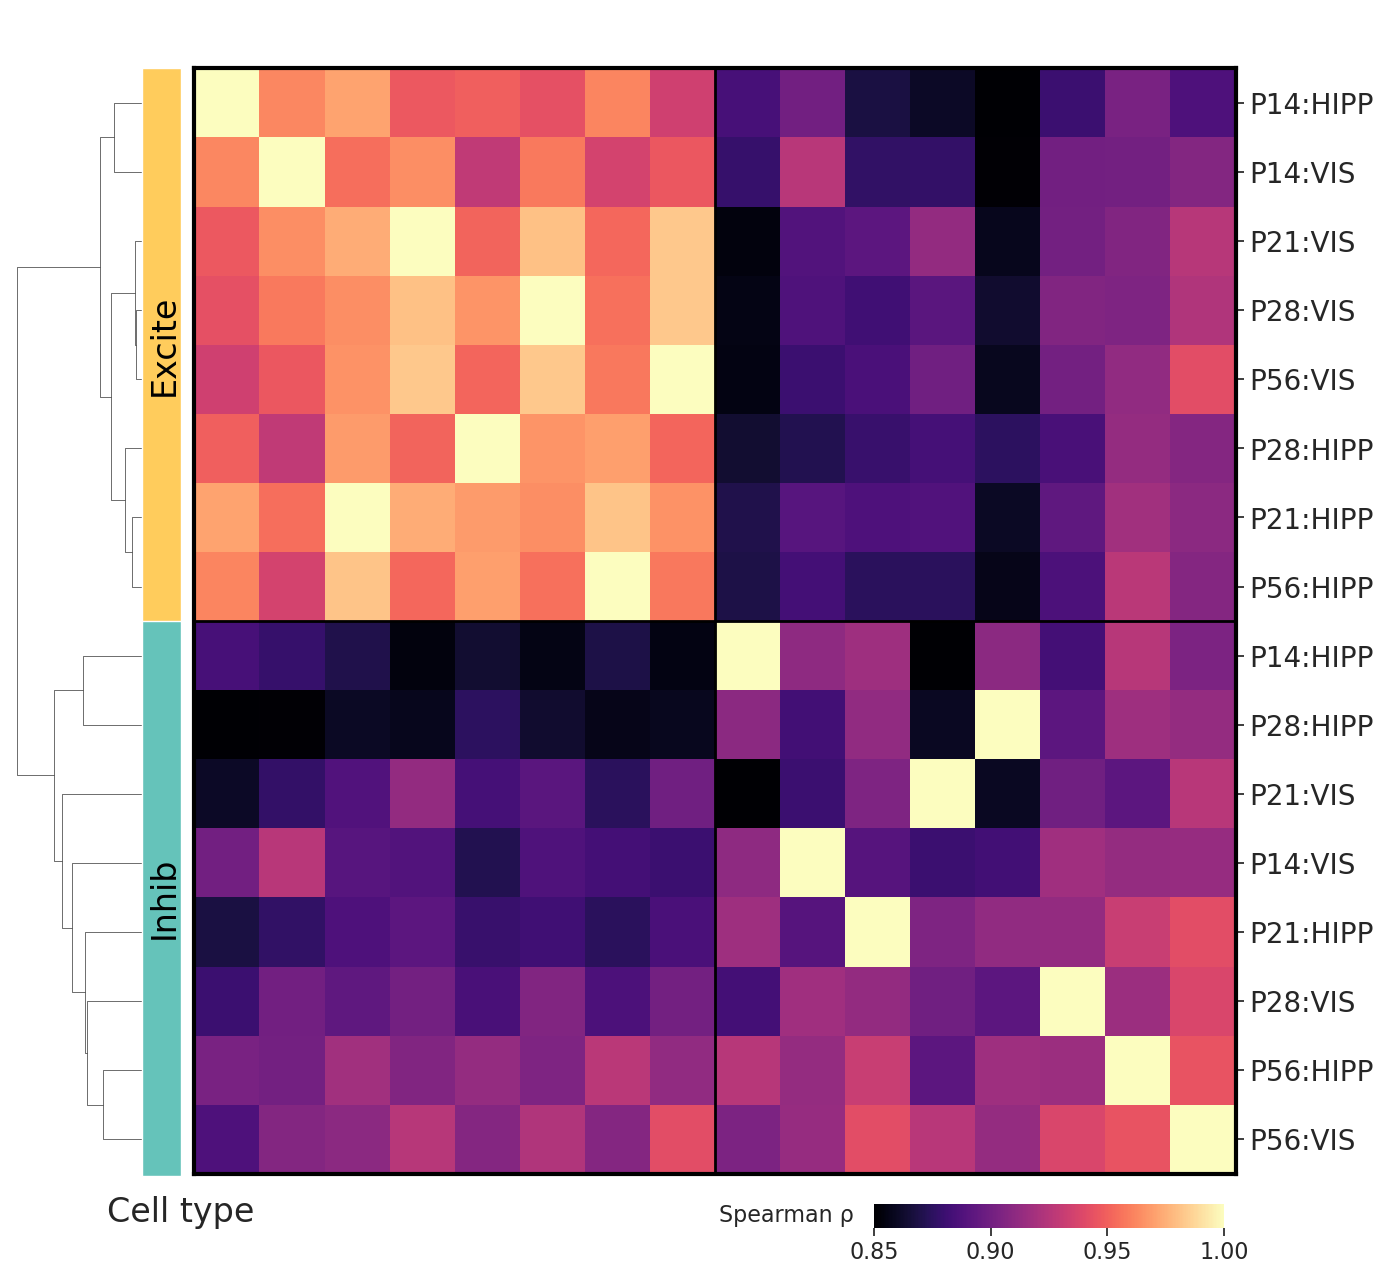

In [18]:
from scipy.spatial.distance import squareform
import scipy.cluster.hierarchy as sch
from matplotlib.patches import Rectangle

# Prepare row order
excite = cnn[cnn["Type"] == "Excite"]["CT"].tolist()
inhib  = cnn[cnn["Type"] == "Inhib"]["CT"].tolist()

row_order = excite + inhib
CN2 = CN.loc[row_order, row_order]

np.fill_diagonal(CN2.values, 1.0)

# Create masked correlation 
CN_masked = CN2.copy()

# Set cross-type correlations LOW
for r in excite:
    for c in inhib:
        CN_masked.loc[r, c] = 0
        CN_masked.loc[c, r] = 0

# Force symmetry and diagonal 
CN_masked = (CN_masked + CN_masked.T) / 2
np.fill_diagonal(CN_masked.values, 1)

# Convert correlation → distance
dist = 1 - CN_masked

# Linkage 2 clusters
condensed = squareform(dist.values, checks=True)
Z = sch.linkage(condensed, method="complete", optimal_ordering=True)

# Side colour labels
row_colours = pd.Series(row_order).map(
    lambda ct: cts_palette["Excite"] if ct in excite else cts_palette["Inhib"]
)

# Clustermap 
sns.set_theme(style="white")

g = sns.clustermap(
    CN2,
    figsize=(14, 12),
    row_colors=row_colours,
    col_cluster=False,
    cmap="magma",
    vmin=0.85,
    vmax=1.0,
    dendrogram_ratio=(0.12, 0.05),
    cbar_kws= {"orientation": "horizontal", "ticks" : [0.85, 0.9, 0.95, 1.0]},
    cbar_pos=(0.63, -0.03, 0.25, 0.02),
    xticklabels=False,
    yticklabels=True,
)

# Rename y-tick labels -> Age:Region
ylabels = []
for ct in g.data2d.index:
    row = cnn.loc[cnn["CT"] == ct].iloc[0]
    label = f"{row['Age']}:{row['Region']}"
    ylabels.append(label)

g.ax_heatmap.set_yticklabels(ylabels, fontsize=20)

# Add border
for spine in g.ax_heatmap.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(3)
    spine.set_color("black")

# Add cluster border line
n_excite = len(excite)
g.ax_heatmap.axhline(n_excite, color="black", linewidth=2)
g.ax_heatmap.axvline(n_excite, color="black", linewidth=2)

# Add cluster labels
ax = g.ax_heatmap

# Excite
ax.text(-0.47, n_excite/2, "Excite",
        rotation=90,
        va="center",
        ha="center",
        fontsize=24,
        color="black",
)

# Inhib
ax.text(-0.47, n_excite + (len(inhib)/2), "Inhib",
        rotation=90,
        va="center",
        ha="center",
        fontsize=24,
        color="black",
)

# Add rectangular colour blocks for cluster labels
ax.add_patch(Rectangle(
    (-0.8, 0),
    0.6,
    n_excite + 0.03,
    transform=ax.transData,
    facecolor=cts_palette["Excite"],
    clip_on=False
))

ax.add_patch(Rectangle(
    (-0.8, n_excite),
    0.6,
    len(inhib) + 0.03,
    transform=ax.transData,
    facecolor=cts_palette["Inhib"],
    clip_on=False
))

g.ax_heatmap.set_ylabel(None)
g.ax_heatmap.text(
    -1.35, 16.8,
    "Cell type",
    va="bottom",
    ha="left",
    fontsize=24,
)

# Add colour bar
cbar = g.cax
cbar.set_ylabel(None)
cbar.text(
    -0.25, 0.03,               
    "Spearman ρ",             
    va="bottom",
    ha="center",
    fontsize=16,
    transform=cbar.transAxes,
)

# Increase tick label font size
for tick in cbar.get_xticklabels():
    tick.set_fontsize(16)

plt.savefig("../plots/heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


## 4. Box Plot of Pairwise Correlation for Excitatory and Inhibitory Types

- Load `altExonUsage_devel_subtype.gz`
- Filter only column with `Inh`, `Excite`, `Granule`, and `NIPC`
- Combine `Exon` and `Gene` to `GE` (`Exon::Gene`)
- Remove rows and columns where >95% of values are missing
- Compute Spearman correlation matrix
- Separate neuronal cell types into 3 types: `Excite`, `Inh`, and `Inhib` 
    - Get the upper triangle matrix for `Excite` (Excite), `Inh` / `Inh_wCR` (Inhib with CajalRetz), and `Inhib` (Inhib without CajalRetz).

**Note:** Because the dataset have many rows with missing values so we do not remove rows with missing data for the subtype neuronal cells. 

In [19]:
subtype_alt = load_subtype_data("../../data/altExonUsage_devel_subtype.gz")
subtype_alt.shape

(5614, 50)

In [20]:
subtype_alt.head(10)

,P14_Hippocampus_ExciteCA,P14_Hippocampus_ExciteDG,P14_Hippocampus_InhCajalRetzius,P14_Hippocampus_InhibNeuron,P14_Hippocampus_GranuleNB,P14_Hippocampus_NIPCs,P14_VisCortex_ExciteL23,P14_VisCortex_ExciteL4,P14_VisCortex_ExciteL5,P14_VisCortex_ExciteL6,...,P56_Hippocampus_InhibNeuron,P56_Hippocampus_GranuleNB,P56_Hippocampus_NIPCs,P56_VisCortex_ExciteL23,P56_VisCortex_ExciteL4,P56_VisCortex_ExciteL5,P56_VisCortex_ExciteL6,P56_VisCortex_ExciteNP,P56_VisCortex_InhibNeuron,P56_VisCortex_NIPCs
GE,,,,,,,,,,,,,,,,,,,,,
chr1_186690721_186690804_-::ENSMUSG00000039239.14,0.000000,0.000000,NaN,NaN,0.068807,0.000000,NaN,NaN,NaN,NaN,...,NaN,0.060606,NaN,NaN,NaN,NaN,0.000000,NaN,0.125000,NaN
chr1_83384894_83384972_-::ENSMUSG00000026163.17,0.638009,0.585062,0.623482,0.730769,0.465541,0.500000,0.675266,0.710586,0.716634,0.718121,...,0.700000,0.485380,NaN,0.783028,0.812673,0.714609,0.711230,0.730539,0.712150,0.923077
chr1_172279313_172279467_-::ENSMUSG00000007097.14,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.961538,NaN,0.947368,NaN,NaN,NaN
chr1_163253977_163254048_-::ENSMUSG00000026586.16,0.545455,NaN,NaN,NaN,NaN,0.692308,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chr1_16486020_16486150_-::ENSMUSG00000025920.19,0.202703,0.207547,0.033898,0.031250,0.075092,0.050725,0.228916,0.326531,0.238318,0.203822,...,0.042857,0.105882,0.090909,0.261146,0.249448,0.200342,0.197258,0.117450,0.145867,0.145833
chr1_162675605_162675841_-::ENSMUSG00000040225.15,0.727273,0.888889,0.676471,NaN,0.778378,0.481818,0.750000,0.822581,0.837500,0.819048,...,0.833333,0.684211,0.428571,0.895833,0.881690,0.948454,0.911638,0.851064,0.959184,0.680000
chr1_30837105_30837266_-::ENSMUSG00000048874.15,0.162879,0.155251,0.104651,0.000000,0.270396,0.445312,0.095652,0.138889,0.148607,0.140078,...,0.196721,0.258621,0.433333,0.182674,0.205684,0.146067,0.169761,0.205128,0.246057,0.454545
chr1_69685694_69685797_-::ENSMUSG00000025997.13,0.096774,NaN,NaN,NaN,0.020833,0.157895,0.050000,0.000000,0.000000,NaN,...,NaN,NaN,NaN,0.150000,0.035714,NaN,0.111111,NaN,0.133333,0.016667
chr1_135426931_135427041_-::ENSMUSG00000041879.13,0.000000,0.000000,NaN,NaN,0.084507,0.024390,0.000000,0.057692,0.016667,0.181818,...,NaN,NaN,NaN,0.073171,0.163522,0.108696,0.125874,0.050000,0.261905,NaN


In [21]:
CN_subtype = compute_spearman_corr(subtype_alt)
CN_subtype

,P14_Hippocampus_ExciteCA,P14_Hippocampus_ExciteDG,P14_Hippocampus_InhCajalRetzius,P14_Hippocampus_InhibNeuron,P14_Hippocampus_GranuleNB,P14_Hippocampus_NIPCs,P14_VisCortex_ExciteL23,P14_VisCortex_ExciteL4,P14_VisCortex_ExciteL5,P14_VisCortex_ExciteL6,...,P56_Hippocampus_InhibNeuron,P56_Hippocampus_GranuleNB,P56_Hippocampus_NIPCs,P56_VisCortex_ExciteL23,P56_VisCortex_ExciteL4,P56_VisCortex_ExciteL5,P56_VisCortex_ExciteL6,P56_VisCortex_ExciteNP,P56_VisCortex_InhibNeuron,P56_VisCortex_NIPCs
P14_Hippocampus_ExciteCA,1.000000,0.903152,0.844871,0.854152,0.864276,0.728453,0.908105,0.913180,0.901889,0.903872,...,0.881449,0.843558,0.683060,0.845749,0.839708,0.845271,0.850114,0.826294,0.838173,0.712052
P14_Hippocampus_ExciteDG,0.903152,1.000000,0.853381,0.816226,0.868174,0.713901,0.901751,0.892937,0.892458,0.894732,...,0.876448,0.852861,0.660150,0.856918,0.850808,0.847753,0.862179,0.837582,0.821291,0.714405
P14_Hippocampus_InhCajalRetzius,0.844871,0.853381,1.000000,0.840548,0.848438,0.717883,0.836029,0.823774,0.830064,0.830156,...,0.874355,0.834960,0.680586,0.795302,0.798637,0.809947,0.812249,0.812833,0.857380,0.713226
P14_Hippocampus_InhibNeuron,0.854152,0.816226,0.840548,1.000000,0.821663,0.654119,0.835992,0.845834,0.841815,0.847488,...,0.867181,0.823602,0.608415,0.768292,0.805053,0.804910,0.810681,0.821024,0.870312,0.704879
P14_Hippocampus_GranuleNB,0.864276,0.868174,0.848438,0.821663,1.000000,0.841722,0.835852,0.833095,0.837708,0.834887,...,0.819091,0.921678,0.788192,0.745183,0.734735,0.746273,0.747265,0.726511,0.797122,0.807514
P14_Hippocampus_NIPCs,0.728453,0.713901,0.717883,0.654119,0.841722,1.000000,0.663555,0.637254,0.670438,0.645361,...,0.640539,0.793189,0.923574,0.569400,0.583388,0.592320,0.605696,0.568496,0.642379,0.873139
P14_VisCortex_ExciteL23,0.908105,0.901751,0.836029,0.835992,0.835852,0.663555,1.000000,0.928472,0.937337,0.935459,...,0.867832,0.821595,0.587346,0.885223,0.872498,0.872924,0.890873,0.859351,0.848228,0.664976
P14_VisCortex_ExciteL4,0.913180,0.892937,0.823774,0.845834,0.833095,0.637254,0.928472,1.000000,0.943232,0.940289,...,0.877514,0.810495,0.574427,0.862700,0.875528,0.870224,0.877720,0.855593,0.849858,0.657952
P14_VisCortex_ExciteL5,0.901889,0.892458,0.830064,0.841815,0.837708,0.670438,0.937337,0.943232,1.000000,0.946725,...,0.887454,0.817440,0.588700,0.860533,0.872419,0.867253,0.883150,0.838459,0.846414,0.651273
P14_VisCortex_ExciteL6,0.903872,0.894732,0.830156,0.847488,0.834887,0.645361,0.935459,0.940289,0.946725,1.000000,...,0.878846,0.823845,0.601521,0.853000,0.865568,0.881526,0.873865,0.847447,0.846692,0.659722


In [22]:
df_4b = preprocess_subtype(CN_subtype)

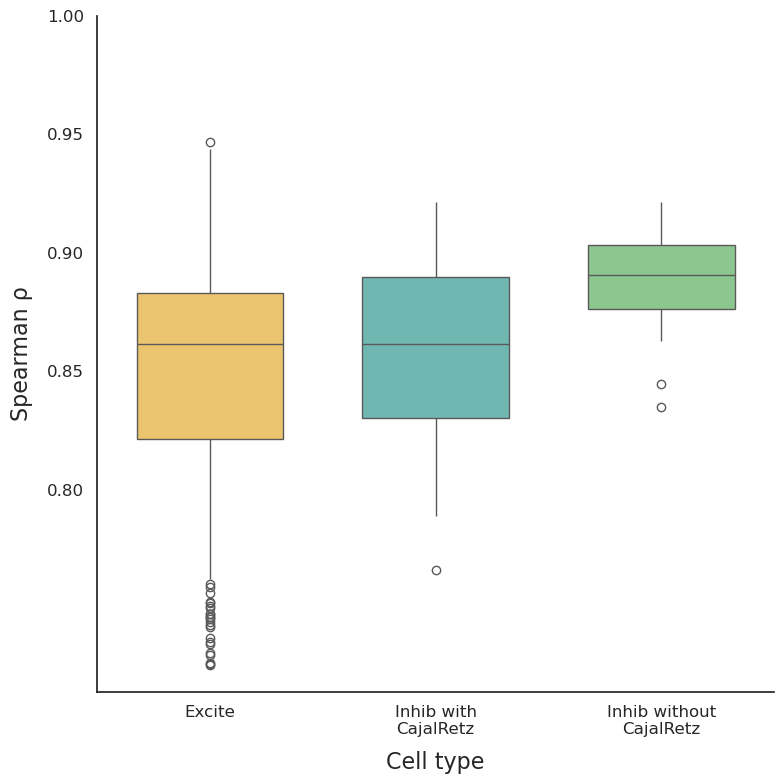

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

cts_pal2 = {'Excite': '#ffcc5c', 'Inhib with\nCajalRetz': '#65c3ba', 'Inhib without\nCajalRetz': '#82d188'}

bplot_label = {
    "Excite": "Excite",
    "Inh_wCR": "Inhib with\nCajalRetz",
    "Inhib": "Inhib without\nCajalRetz"
}

bplot = df_4b.copy()
bplot["Type"] = bplot["Type"].map(bplot_label)

plt.figure(figsize=(8,8))

sns.boxplot(
    data=bplot, 
    x="Type", 
    y="CorValue", 
    hue="Type",
    whis=1.0,
    showcaps=False,
    palette=cts_pal2,
    width=0.65,
)

sns.despine()

plt.xlabel("Cell type", fontsize=16,labelpad=10)
plt.ylabel("Spearman ρ", fontsize=16, labelpad=10)

plt.yticks([0.80, 0.85, 0.90, 0.95, 1.00], fontsize=12)
plt.xticks(fontsize=12)

plt.tight_layout()

plt.savefig("../plots/boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Compute Transition Correlations of Exon Inclusion for Each Cell Type in Each Brain Region

In [24]:
timepoints = ["P14", "P21", "P28", "P56"]
regions = ["Hippocampus", "VisCortex"]

# pairs of timepoints
combs = np.array([
    timepoints[0:3],  
    timepoints[1:4]   
])

In [25]:
cor_neurons_ci = []

for region in regions:
    for c in range(combs.shape[1]):  # 3 transitions
        tps = combs[:, c]  # start -> end
        for ct in cts:
            # columns containing start timepoint, region, and cell type
            col1 = [col for col in type_neurons.columns if tps[0] in col and region in col and ct in col]
            col2 = [col for col in type_neurons.columns if tps[1] in col and region in col and ct in col]
            if len(col1) == 0 or len(col2) == 0:
                continue
            v1 = type_neurons[col1].mean(axis=1)
            v2 = type_neurons[col2].mean(axis=1)
            r, lci, uci = compute_spearman_ci(v1, v2)
            cor_neurons_ci.append({
                "Estimate": r,
                "LCI": lci,
                "UCI": uci,
                "Region": region,
                "Cell type": ct,
                "Transition": f"{tps[0]} → {tps[1]}"
            })

cor_neurons_df = pd.DataFrame(cor_neurons_ci)
cor_neurons_df

,Estimate,LCI,UCI,Region,Cell type,Transition
0,0.971003,0.965060,0.975948,Hippocampus,Excite,P14 → P21
1,0.916648,0.900128,0.930536,Hippocampus,Inhib,P14 → P21
2,0.968928,0.962567,0.974222,Hippocampus,Excite,P21 → P28
3,0.911842,0.894421,0.926499,Hippocampus,Inhib,P21 → P28
4,0.970060,0.963926,0.975163,Hippocampus,Excite,P28 → P56
5,0.916498,0.899949,0.930409,Hippocampus,Inhib,P28 → P56
6,0.964306,0.957020,0.970376,VisCortex,Excite,P14 → P21
7,0.880438,0.857275,0.900044,VisCortex,Inhib,P14 → P21
8,0.980269,0.976202,0.983647,VisCortex,Excite,P21 → P28
9,0.899474,0.879763,0.916098,VisCortex,Inhib,P21 → P28


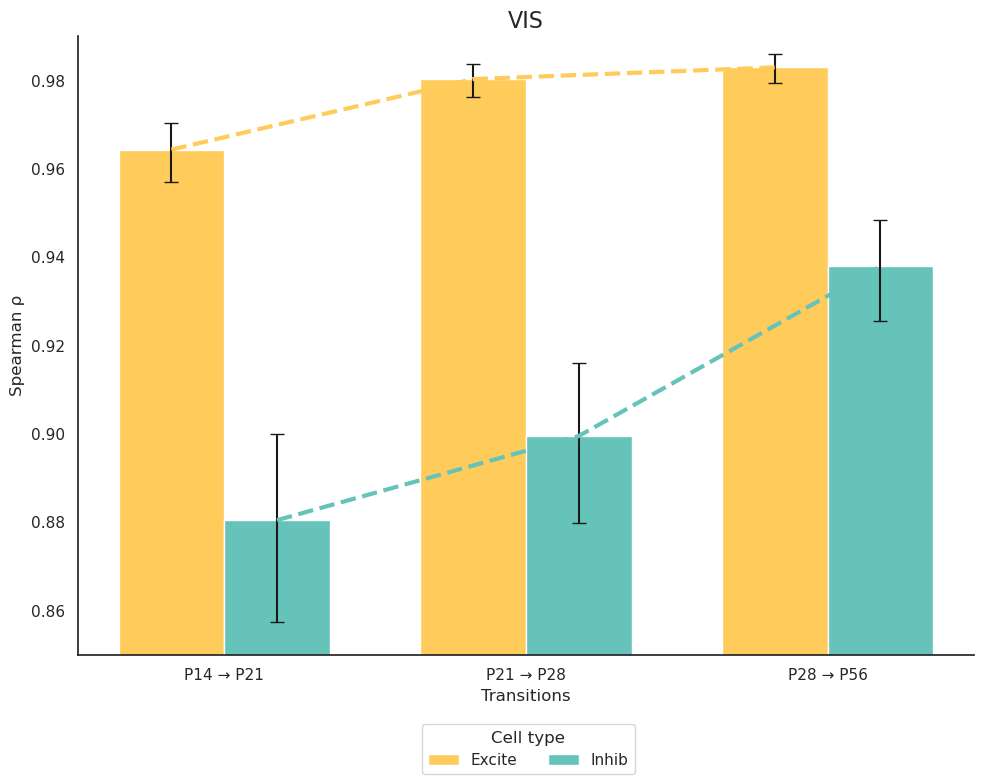

In [26]:
# Figure 4c: transition correlations, VisCortex only
vis_plot = cor_neurons_df[cor_neurons_df["Region"]=="VisCortex"]

# Order by Transition
transitions = list(vis_plot["Transition"].unique())

plt.figure(figsize=(10,8))
ax = plt.gca()

# x positions for transitions
x = np.arange(len(transitions))
width = 0.35   # width of each bar

# Plot each cell type separately
for i, ct in enumerate(cts):
    ct_df = vis_plot[vis_plot["Cell type"] == ct].sort_values("Transition")

    # x positions offset for each group
    xs = x - width/2 if ct == "Excite" else x + width/2

    # means
    ys = ct_df["Estimate"].values

    # asymmetric error bars
    yerr = np.vstack([
        ys - ct_df["LCI"].values,
        ct_df["UCI"].values - ys
    ])

    # draw bars
    ax.bar(
        xs, ys, width,
        yerr=yerr,
        label=ct,
        capsize=5,
        color=cts_palette[ct]
    )

    # store x positions for trend lines
    ct_df["xpos"] = xs

    # trend line
    ax.plot(xs, ys, color=cts_palette[ct], linestyle="--", linewidth=3.0)

ax.set_xticks(x)
ax.set_xticklabels(transitions)
ax.set_ylim(0.85, 0.99)
ax.set_ylabel("Spearman ρ")
ax.set_xlabel("Transitions")
ax.set_title("VIS", fontsize=16)

sns.despine()
plt.legend(title="Cell type", bbox_to_anchor=(0.63, -0.1), ncol=2)
plt.tight_layout()
plt.savefig("../plots/VIS.png", dpi=300, bbox_inches="tight")
plt.show()

In [27]:
vis_plot

,Estimate,LCI,UCI,Region,Cell type,Transition
6,0.964306,0.957020,0.970376,VisCortex,Excite,P14 → P21
7,0.880438,0.857275,0.900044,VisCortex,Inhib,P14 → P21
8,0.980269,0.976202,0.983647,VisCortex,Excite,P21 → P28
9,0.899474,0.879763,0.916098,VisCortex,Inhib,P21 → P28
10,0.982918,0.979392,0.985846,VisCortex,Excite,P28 → P56
11,0.937927,0.925460,0.948364,VisCortex,Inhib,P28 → P56


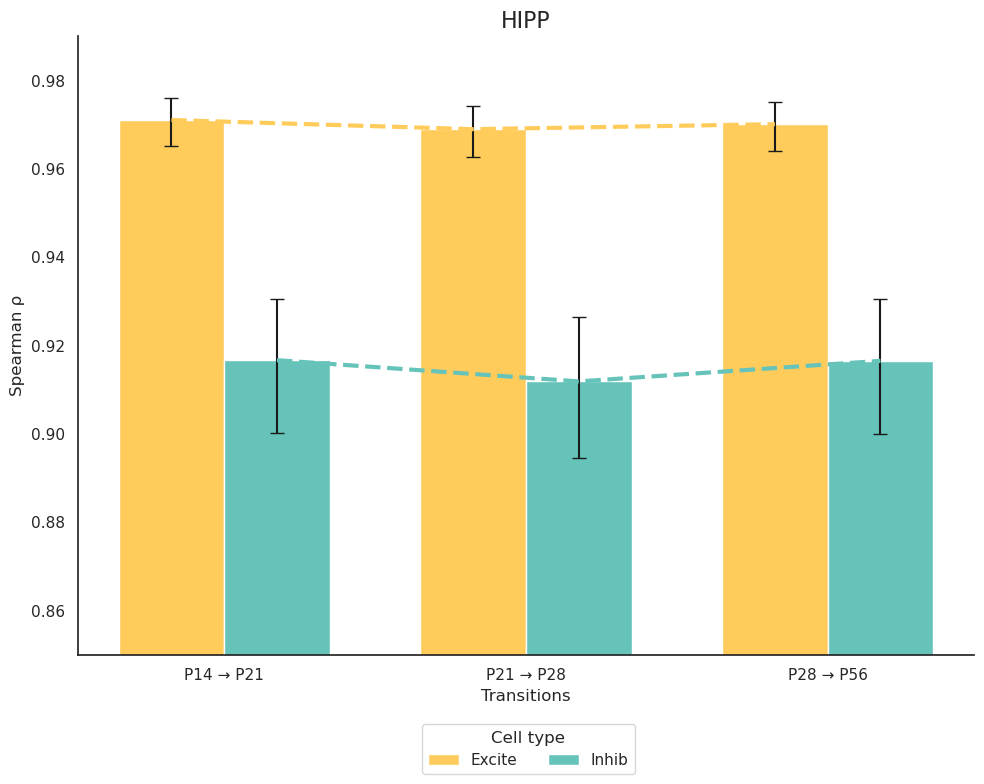

In [28]:
# transition correlations, Hippocampus only
hipp_plot = cor_neurons_df[cor_neurons_df["Region"]=="Hippocampus"]

# Order by Transition
transitions = list(hipp_plot["Transition"].unique())

plt.figure(figsize=(10,8))
ax = plt.gca()

# x positions for transitions
x = np.arange(len(transitions))
width = 0.35   # width of each bar

# Plot each cell type separately
for i, ct in enumerate(cts):
    ct_df = hipp_plot[hipp_plot["Cell type"] == ct].sort_values("Transition")

    # x positions offset for each group
    xs = x - width/2 if ct == "Excite" else x + width/2

    # means
    ys = ct_df["Estimate"].values

    # asymmetric error bars
    yerr = np.vstack([
        ys - ct_df["LCI"].values,
        ct_df["UCI"].values - ys
    ])

    # draw bars
    ax.bar(
        xs, ys, width,
        yerr=yerr,
        label=ct,
        capsize=5,
        color=cts_palette[ct]
    )

    # store x positions for trend lines
    ct_df["xpos"] = xs

    # trend line
    ax.plot(xs, ys, color=cts_palette[ct], linestyle="--", linewidth=3.0)

ax.set_xticks(x)
ax.set_xticklabels(transitions)
ax.set_ylim(0.85, 0.99)
ax.set_ylabel("Spearman ρ")
ax.set_xlabel("Transitions")
ax.set_title("HIPP", fontsize=16)

sns.despine()
plt.legend(title="Cell type", bbox_to_anchor=(0.63, -0.1), ncol=2)
plt.tight_layout()
plt.savefig("../plots/HIPP.png", dpi=300, bbox_inches="tight")
plt.show()

In [29]:
hipp_plot

,Estimate,LCI,UCI,Region,Cell type,Transition
0,0.971003,0.965060,0.975948,Hippocampus,Excite,P14 → P21
1,0.916648,0.900128,0.930536,Hippocampus,Inhib,P14 → P21
2,0.968928,0.962567,0.974222,Hippocampus,Excite,P21 → P28
3,0.911842,0.894421,0.926499,Hippocampus,Inhib,P21 → P28
4,0.970060,0.963926,0.975163,Hippocampus,Excite,P28 → P56
5,0.916498,0.899949,0.930409,Hippocampus,Inhib,P28 → P56


## 6. Compute Correlations of Exon Inclusion for Each Cell Type Between the Visual Cortex and the Hippocampus

In [30]:
cor_neu_reg = []

for tp in timepoints:
    for ct in cts:
        col1 = [col for col in type_neurons.columns if tp in col and "Hippocampus" in col and ct in col]
        col2 = [col for col in type_neurons.columns if tp in col and "VisCortex" in col and ct in col]
        if len(col1) == 0 or len(col2) == 0:
            continue
        v1 = type_neurons[col1].iloc[:,0]
        v2 = type_neurons[col2].iloc[:,0]
        r, lci, uci = compute_spearman_ci(v1, v2)
        cor_neu_reg.append({
            "Estimate": r,
            "LCI": lci,
            "UCI": uci,
            "Timepoint": tp,
            "Cell type": ct
        })

cor_neu_reg_df = pd.DataFrame(cor_neu_reg)
cor_neu_reg_df

,Estimate,LCI,UCI,Timepoint,Cell type
0,0.962237,0.954538,0.968653,P14,Excite
1,0.910373,0.892679,0.925265,P14,Inhib
2,0.973686,0.968284,0.978179,P21,Excite
3,0.904615,0.885851,0.920424,P21,Inhib
4,0.966287,0.959397,0.972025,P28,Excite
5,0.891848,0.870743,0.909672,P28,Inhib
6,0.957619,0.949003,0.964806,P56,Excite
7,0.944796,0.933661,0.954106,P56,Inhib


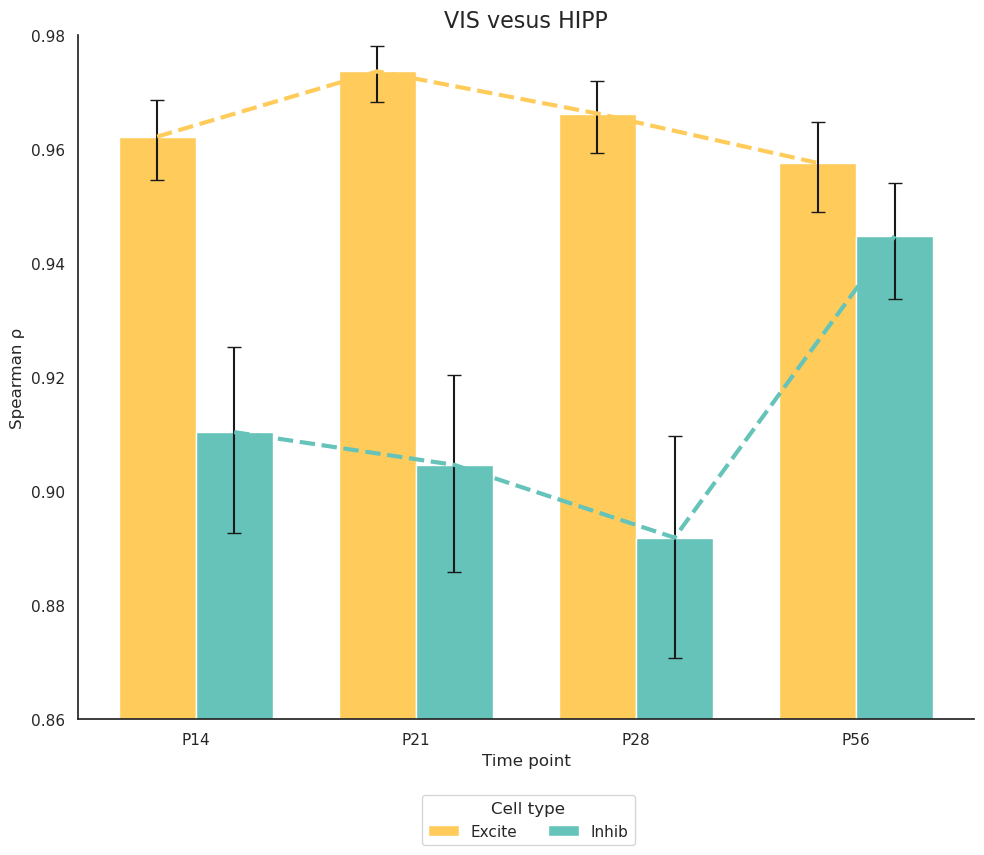

In [31]:
plt.figure(figsize=(10,8))
ax = plt.gca()

# Order by Timepoint
cor_neu_reg_df["Timepoint"] = pd.Categorical(
    cor_neu_reg_df["Timepoint"],
    categories=timepoints,
    ordered=True
)

# Positions for Timepoints
x = np.arange(len(timepoints))
width = 0.35 

# Plot each cell type separately 
for ct in cts:
    ct_df = cor_neu_reg_df[cor_neu_reg_df["Cell type"] == ct].sort_values("Timepoint")

    # offset each group 
    xs = x - width/2 if ct == "Excite" else x + width/2

    ys = ct_df["Estimate"].values

    # Error bars
    yerr = np.vstack([
        np.maximum(0, ys - ct_df["LCI"].values),
        np.maximum(0, ct_df["UCI"].values - ys)
    ])

    # bar plot with correct yerr
    ax.bar(
        xs,
        ys,
        width,
        yerr=yerr,
        capsize=5,
        color=cts_palette[ct],
        label=ct
    )

    # store x positions for trend lines
    ct_df["xpos"] = xs

    # trend line
    ax.plot(xs, ys, color=cts_palette[ct], linestyle="--", linewidth=3.0)

ax.set_ylim(0.86, 0.98)
ax.set_ylabel("Spearman ρ")
ax.set_xticks(x)
ax.set_xticklabels(timepoints)
ax.set_xlabel("Time point")
ax.set_title("VIS vesus HIPP", fontsize=16)

sns.despine()
plt.legend(title="Cell type", bbox_to_anchor=(0.63, -0.1), ncol=2)
plt.tight_layout()
plt.savefig("../plots/VISversusHIPP.png", dpi=300, bbox_inches="tight")
plt.show()
